In [3]:
import pandas as pd

# 1. Load the data (if you haven't already)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

# 2. Basic Cleaning (The 'Data Analyst' essentials)
# Remove rows without a CustomerID (we can't track them!)
df = df.dropna(subset=['CustomerID'])

# Remove cancellations (Invoice numbers starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

# Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 3. Create a 'TotalSum' column (Quantity * UnitPrice)
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

print(f"Dataset cleaned! Remaining rows: {len(df)}")
df.head()

Dataset cleaned! Remaining rows: 397884


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
import datetime as dt

# 1. Fix the "Current Date" for the analysis
# We take the latest date in the data and add 1 day
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Group by CustomerID and calculate R, F, and M
# This is the Python equivalent of a SQL 'GROUP BY' with multiple 'AGGS'
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                # Frequency
    'TotalSum': 'sum'                                    # Monetary
})

# 3. Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

print("RFM Table Created!")
rfm.head()

RFM Table Created!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


A customer with a Recency of 5 is much "better" than a customer with a Recency of 300. However, for Monetary, a value of 1000 is "better" than 50.

We need to put these on a scale of 1–5 so we can compare them fairly. This is called Binning (or using Percentiles).

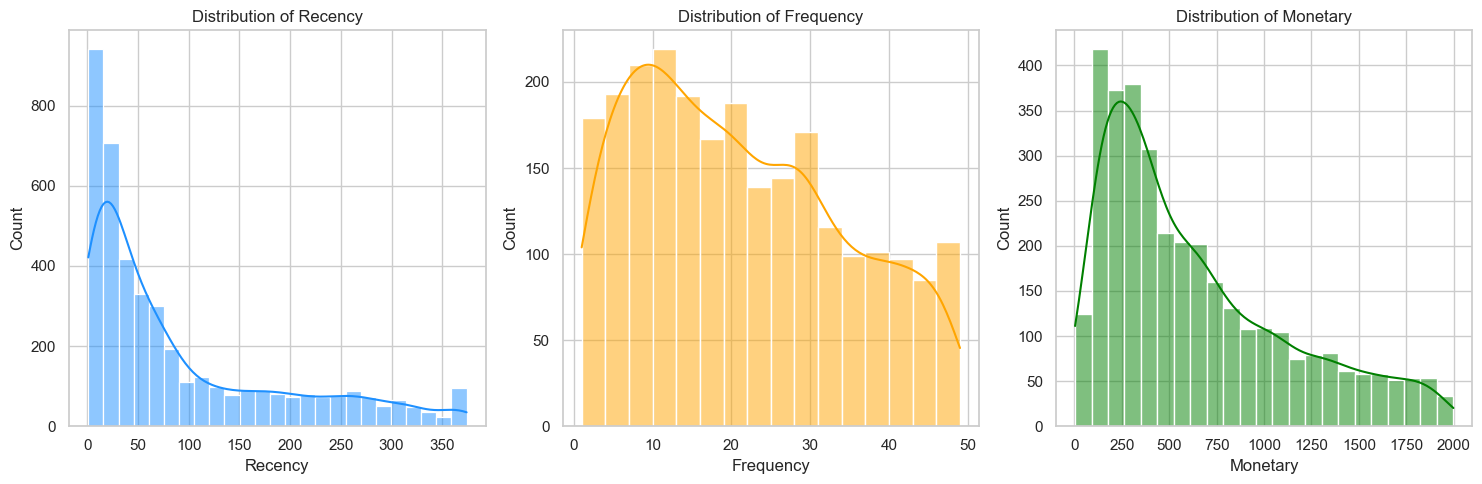

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Create a 1x3 subplot for R, F, and M
plt.figure(figsize=(15, 5))

# Plot Recency
plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True, color='dodgerblue')
plt.title('Distribution of Recency')

# Plot Frequency (we limit to 50 to see the bulk of data)
plt.subplot(1, 3, 2)
sns.histplot(rfm[rfm['Frequency'] < 50]['Frequency'], kde=True, color='orange')
plt.title('Distribution of Frequency')

# Plot Monetary (we limit to 2000 for better visibility)
plt.subplot(1, 3, 3)
sns.histplot(rfm[rfm['Monetary'] < 2000]['Monetary'], kde=True, color='green')
plt.title('Distribution of Monetary')

plt.tight_layout()
plt.show()

In [6]:
# Create labels for our quintiles
r_labels = range(5, 0, -1) # 5 is best (most recent), 1 is worst
f_labels = range(1, 6)     # 5 is best (most frequent)
m_labels = range(1, 6)     # 5 is best (highest spender)

# Assign these labels to 5 equal-sized groups
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# Create a combined RFM Group string (e.g., "555" is a perfect customer)
rfm['RFM_Group'] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)

# Calculate a total RFM Score (sum of R+F+M)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

print("Scoring Complete!")
rfm.head()

Scoring Complete!


,Recency,Frequency,Monetary,R,F,M,RFM_Group,RFM_Score
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,7
12347.0,2,182,4310.00,5,5,5,555,15
12348.0,75,31,1797.24,2,3,4,234,9
12349.0,19,73,1757.55,4,4,4,444,12
12350.0,310,17,334.40,1,2,2,122,5


In [7]:
def segment_me(df):
    if df['RFM_Score'] >= 13:
        return 'Champions'
    elif (df['RFM_Score'] >= 10) and (df['RFM_Score'] < 13):
        return 'Loyalists'
    elif (df['RFM_Score'] >= 7) and (df['RFM_Score'] < 10):
        return 'Potential Loyalists'
    elif (df['RFM_Score'] >= 4) and (df['RFM_Score'] < 7):
        return 'At Risk'
    else:
        return 'Hibernating'

# Apply the function to create a 'Segment' column
rfm['Segment'] = rfm.apply(segment_me, axis=1)

# Check the distribution of our new segments
print(rfm['Segment'].value_counts())
rfm.head()

Segment
Potential Loyalists    1122
Loyalists              1026
At Risk                1005
Champions               927
Hibernating             258
Name: count, dtype: int64


,Recency,Frequency,Monetary,R,F,M,RFM_Group,RFM_Score,Segment
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,7,Potential Loyalists
12347.0,2,182,4310.00,5,5,5,555,15,Champions
12348.0,75,31,1797.24,2,3,4,234,9,Potential Loyalists
12349.0,19,73,1757.55,4,4,4,444,12,Loyalists
12350.0,310,17,334.40,1,2,2,122,5,At Risk


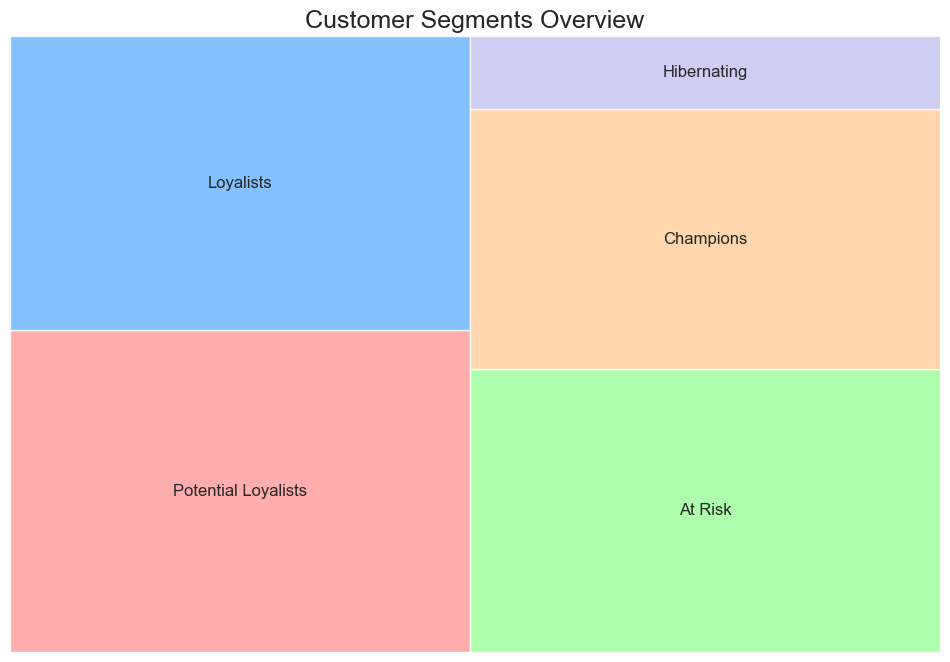

In [10]:
import squarify

# Prepare data for the treemap
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Plotting
plt.figure(figsize=(12, 8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

squarify.plot(sizes=segment_counts['Count'], 
              label=segment_counts['Segment'], 
              alpha=0.8, 
              color=colors)

plt.title("Customer Segments Overview", fontsize=18)
plt.axis('off')
plt.show()

In [12]:
import sqlite3

# 1. Connect to a database (it will create 'ecommerce.db' if it doesn't exist)
conn = sqlite3.connect('ecommerce.db')

# 2. Push the RFM table into the database
# 'if_exists="replace"' ensures you can run this cell multiple times
rfm.to_sql('rfm_analysis', conn, if_exists='replace', index=True)

# 3. Close the connection
conn.close()

print("Database 'ecommerce.db' created successfully in your folder!")

Database 'ecommerce.db' created successfully in your folder!


In [13]:
# Re-connect to read the data using SQL
conn = sqlite3.connect('ecommerce.db')

# Write a SQL Query to find the top 5 'Champions' by Monetary value
query = """
SELECT CustomerID, Recency, Frequency, Monetary, Segment
FROM rfm_analysis
WHERE Segment = 'Champions'
ORDER BY Monetary DESC
LIMIT 5
"""

# Execute the query and show results
top_champions = pd.read_sql_query(query, conn)
conn.close()

top_champions

,CustomerID,Recency,Frequency,Monetary,Segment
0,14646.0,2,2076,280206.02,Champions
1,18102.0,1,431,259657.30,Champions
2,17450.0,8,337,194550.79,Champions
3,14911.0,1,5675,143825.06,Champions
4,12415.0,24,714,124914.53,Champions


In [14]:
import sqlite3
import pandas as pd

# 1. Connect to our database
conn = sqlite3.connect('ecommerce.db')

# 2. Advanced SQL: Using a CTE to summarize segments
query = """
WITH SegmentSummary AS (
    SELECT 
        Segment,
        COUNT(CustomerID) AS Total_Customers,
        AVG(Monetary) AS Avg_Spending,
        SUM(Monetary) AS Total_Revenue
    FROM rfm_analysis
    GROUP BY Segment
)
SELECT 
    Segment,
    Total_Customers,
    ROUND(Avg_Spending, 2) AS Avg_Ticket_Size,
    ROUND(Total_Revenue, 2) AS Segment_Value,
    ROUND((Total_Revenue * 100.0 / (SELECT SUM(Monetary) FROM rfm_analysis)), 2) AS Revenue_Share_Pct
FROM SegmentSummary
ORDER BY Total_Revenue DESC;
"""

# 3. Execute and show the "Boardroom" report
summary_report = pd.read_sql_query(query, conn)
conn.close()

summary_report

,Segment,Total_Customers,Avg_Ticket_Size,Segment_Value,Revenue_Share_Pct
0,Champions,927,6505.98,6031046.52,67.68
1,Loyalists,1026,1611.01,1652891.58,18.55
2,Potential Loyalists,1122,798.17,895542.61,10.05
3,At Risk,1005,295.30,296775.48,3.33
4,Hibernating,258,136.25,35151.71,0.39
